In [1]:
 import pandas as pd
 import numpy as np
 import matplotlib.pyplot as plt
 from sklearn.preprocessing import MinMaxScaler
 from tensorflow.keras.models import Sequential
 from tensorflow.keras.layers import Dense, LSTM, Dropout

In [2]:
 # STEP 1: Import file from local system
 from google.colab import files
 uploaded = files.upload()

Saving GOOG.csv to GOOG.csv


In [3]:
 # STEP 2: Load the uploaded CSV
 data = pd.read_csv('GOOG.csv')  # The uploaded filename should match
 print(data.head())

         Date         Open         High          Low        Close  \
0  2020-05-20  1389.579956  1410.420044  1387.250000  1406.719971   
1  2020-05-21  1408.000000  1415.489990  1393.449951  1402.800049   
2  2020-05-22  1396.709961  1412.760010  1391.829956  1410.420044   
3  2020-05-26  1437.270020  1441.000000  1412.130005  1417.020020   
4  2020-05-27  1417.250000  1421.739990  1391.290039  1417.839966   

     Adj Close   Volume  
0  1406.719971  1655400  
1  1402.800049  1385000  
2  1410.420044  1309400  
3  1417.020020  2060600  
4  1417.839966  1685800  


In [7]:
# ✅Extract 'Open' price column for prediction
dataset = data['Open'].values.reshape(-1, 1)

In [8]:
 # ��Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

In [9]:
# Split into training and testing
training_data_len = int(len(dataset) * 0.8)
training_data = dataset[:training_data_len]
testing_data = dataset[training_data_len:]

In [11]:
# Helper function to create sequences
def create_dataset(data, time_step=60):
    X, Y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        Y.append(data[i + time_step, 0])
    return np.array(X), np.array(Y)

In [12]:
 # ⏱Time step
time_step = 60
X_train, Y_train = create_dataset(training_data, time_step)
X_test, Y_test = create_dataset(testing_data, time_step)
print("Dataset length:", len(dataset))
print("Training data length:", len(training_data))
print("Testing data length:", len(testing_data))
print("Time step:", time_step)
X_train, Y_train = create_dataset(training_data, time_step)
X_test, Y_test = create_dataset(testing_data, time_step)
print("X_train shape before reshape:", X_train.shape)
print("X_test shape before reshape:", X_test.shape)

Dataset length: 64
Training data length: 51
Testing data length: 13
Time step: 60
X_train shape before reshape: (0,)
X_test shape before reshape: (0,)


In [13]:
 # ⏱Time step
time_step = 10
X_train, Y_train = create_dataset(training_data, time_step)
X_test, Y_test = create_dataset(testing_data, time_step)

 #  Reshape for LSTM input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [14]:
# Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
# Compile and Train
model.compile(optimizer='adam', loss='mean_squared_error')
history = model.fit(X_train, Y_train, epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 955ms/step - loss: 0.2660 - val_loss: 0.3009
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.2111 - val_loss: 0.1762
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.1427 - val_loss: 0.0708
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0773 - val_loss: 0.0062
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.0423 - val_loss: 0.0431
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0481 - val_loss: 0.1146
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0679 - val_loss: 0.0860
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0577 - val_loss: 0.0324
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0348 - val_loss: 0.0061
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0346 - val_loss: 0.0032
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0413 - val_loss: 0.0040
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0375 - val_loss: 0

In [17]:

#Predict and inverse transform
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
Y_test_actual = scaler.inverse_transform(Y_test.reshape(-1, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step


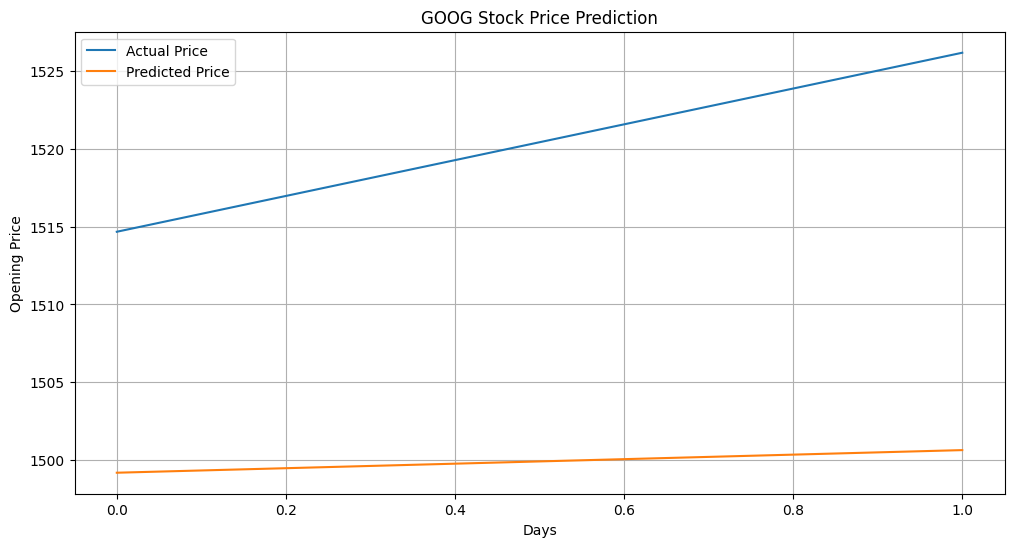

In [19]:
# Plotting the result
plt.figure(figsize=(12, 6))
plt.plot(Y_test_actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title('GOOG Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Opening Price')
plt.legend()
plt.grid(True)
plt.show()